In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully!")
print("Number of classes:", ds_info.features['label'].num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.8FAIGQ_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset loaded successfully!
Number of classes: 5


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

print("Preprocessing Complete!")

Preprocessing Complete!


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True

model = tf.keras.Sequential([
    data_augmentation,
    layers.Rescaling(scale=2./255, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 2,230,277 (8.51 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
history=model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 61s 310ms/step - accuracy: 0.7578 - loss: 0.6796 - val_accuracy: 0.2166 - val_loss: 10.3284
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 274ms/step - accuracy: 0.8498 - loss: 0.4441 - val_accuracy: 0.2166 - val_loss: 23.0695
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 284ms/step - accuracy: 0.8655 - loss: 0.3633 - val_accuracy: 0.2166 - val_loss: 33.1045
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 291ms/step - accuracy: 0.8811 - loss: 0.3451 - val_accuracy: 0.2166 - val_loss: 24.9006
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 287ms/step - accuracy: 0.8995 - loss: 0.2787 - val_accuracy: 0.2153 - val_loss: 11.6362


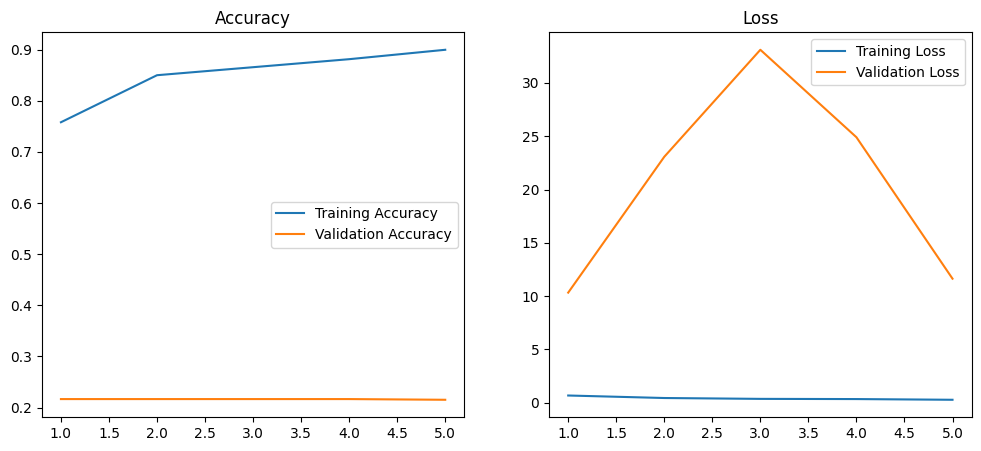

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.2153 - loss: 11.6362
Test Accuracy: 0.21525885164737701
Test Loss: 11.636186599731445


In [ ]:
model.save("flower_classifier_model.keras")

In [ ]:
from google.colab import files
files.download("flower_classifier_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("flower_classifier_model.keras")

In [ ]:
!ls

flower_classifier_model.keras  sample_data


In [ ]:
from google.colab import files
files.download("flower_classifier_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>